In [42]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

In [169]:
%reload_ext autoreload
%autoreload 2



import numpy as np
from numpy.linalg import norm, inv
import matplotlib.pyplot as plt
import importlib
import measurements.state_to_edgepoints as state_to_edgepoints_module
from trajectory.Constants import G

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)

In [44]:

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from measurements.InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_T_c_p, plot_est_dist_xyz, plot_est_dist_xyz_errors, plot_trajs

In [45]:
# === SYSTEM PARAMETERS ===
MOON_RADIUS_KM = 1737.4
MOON_MU = 4902.8  # km3/s2
CAMERA_FOCAL_LENGTH_MM = 2500  # mm (example, adjust as needed)
CAMERA_PIXEL_SIZE_UM = 5.5  # um
CAMERA_RESOLUTION = (2048, 2048)  # pixels

# === FILTER TUNING ===
Q_POS_VARIANCE = 1.0  # km2
Q_VEL_VARIANCE = 0.0001  # km2/s2
R_MEAS_VARIANCE = 1000  # km2

# === TIME ===
TRAJECTORY_DT = 1000  # seconds
N_STEPS = 50

# === FRAME CONVENTIONS ===
# - Planet frame (P): Moon-centered inertial
# - Camera frame (C): Spacecraft-centered, +Z toward nadir
# - T_p_c: Rotation matrix from planet to camera frame

In [46]:
f, mu, n_pixels = Set_camera()  # Sagitta camera parameters

# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = MOON_RADIUS_KM  # km
moon_mu = MOON_MU  # km3/s2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
print(body)

w, h = 1280, 720  # Camera resolution
# Camera calibration matrix K (focal length in pixels, principal point at center)
K = np.array([
    [1120.0, 0.0, w / 2.0],
    [0.0, 1120.0, h / 2.0],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)

Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 45980.8058633618s


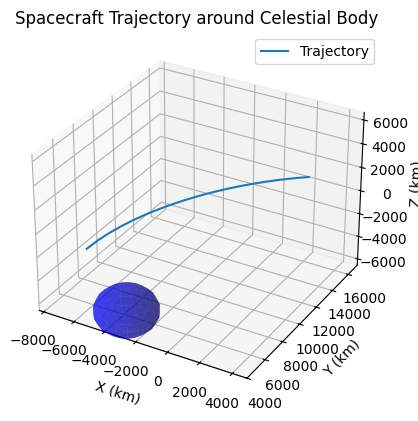

24
0


In [47]:
pos = np.array([-5000, 4000, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op.states, body_struct)

print(len(op.states))
print(op.ts[0])


In [48]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(op.states, op.ts, body_struct, cam_offset, camera_spec_ellie, 10)


State at t=0.0s: [-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]
State at t=1000.0s: [-4.958e+03  5.038e+03  9.916e+01  8.034e-02  1.002e+00 -1.607e-03]
State at t=2000.0s: [-4.846e+03  6.007e+03  9.692e+01  1.401e-01  9.355e-01 -2.802e-03]
State at t=3000.0s: [-4.682e+03  6.911e+03  9.365e+01  1.853e-01  8.743e-01 -3.707e-03]
State at t=4000.0s: [-4.479e+03  7.757e+03  8.958e+01  2.201e-01  8.188e-01 -4.402e-03]
State at t=5000.0s: [-4.245e+03  8.551e+03  8.490e+01  2.472e-01  7.683e-01 -4.944e-03]
State at t=6000.0s: [-3.986e+03  9.295e+03  7.973e+01  2.685e-01  7.222e-01 -5.370e-03]
State at t=7000.0s: [-3.709e+03  9.996e+03  7.418e+01  2.854e-01  6.800e-01 -5.707e-03]
State at t=8000.0s: [-3.417e+03  1.066e+04  6.834e+01  2.988e-01  6.412e-01 -5.976e-03]
State at t=9000.0s: [-3.113e+03  1.128e+04  6.225e+01  3.095e-01  6.053e-01 -6.190e-03]


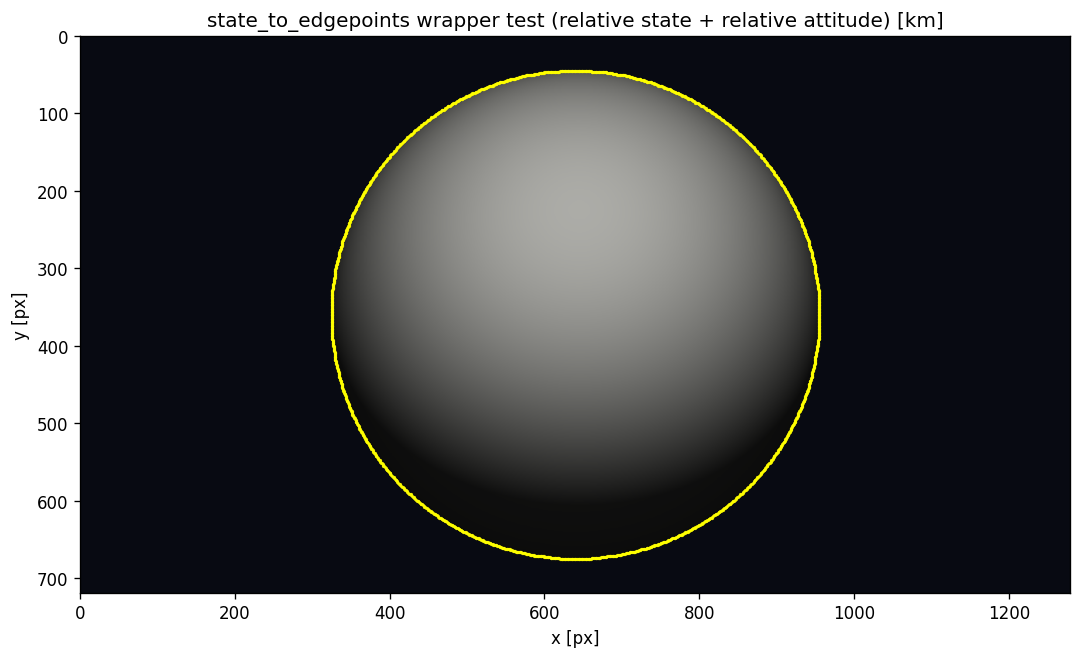

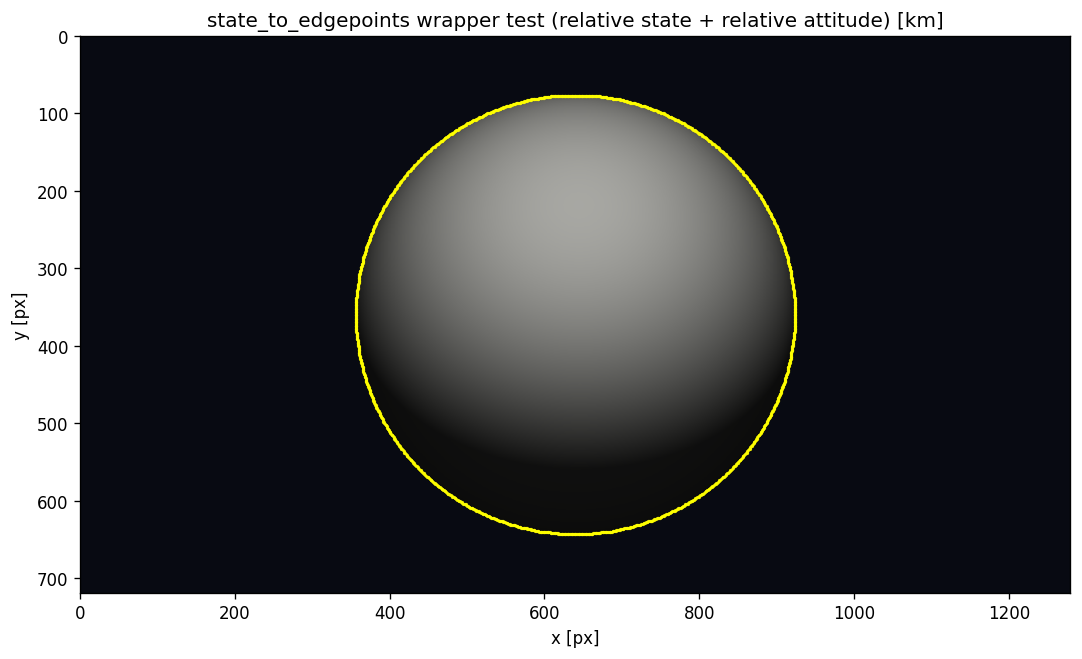

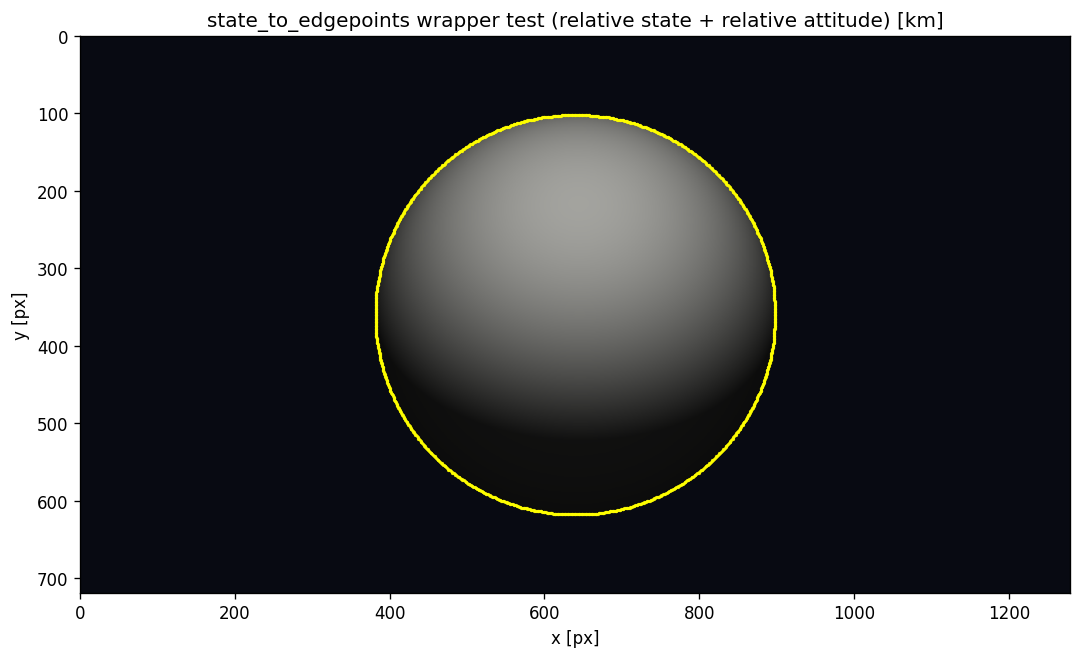

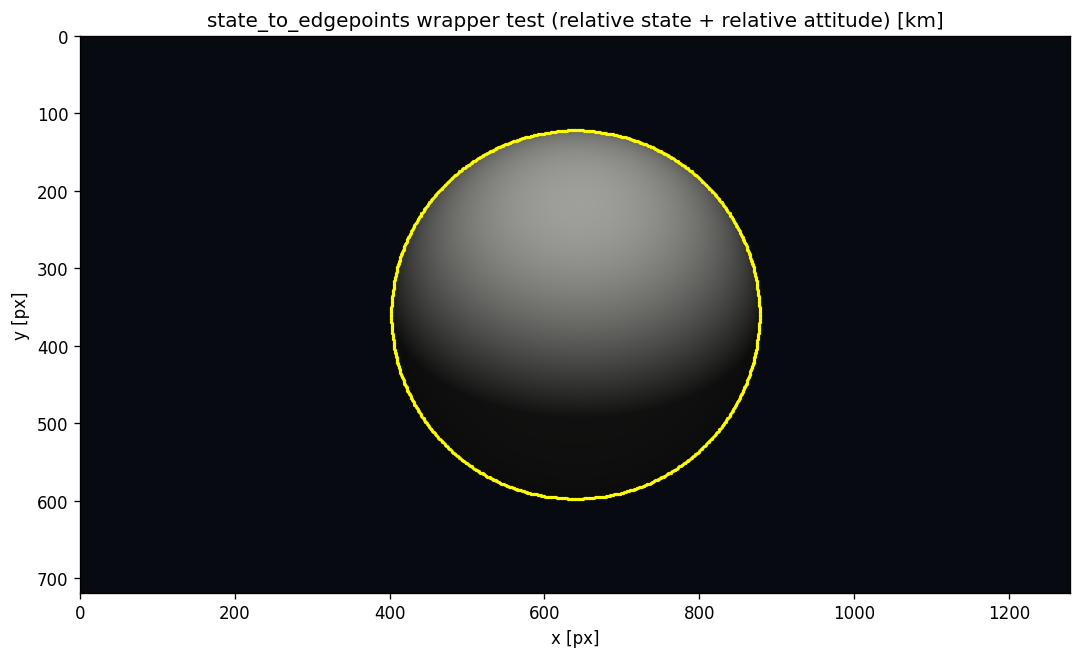

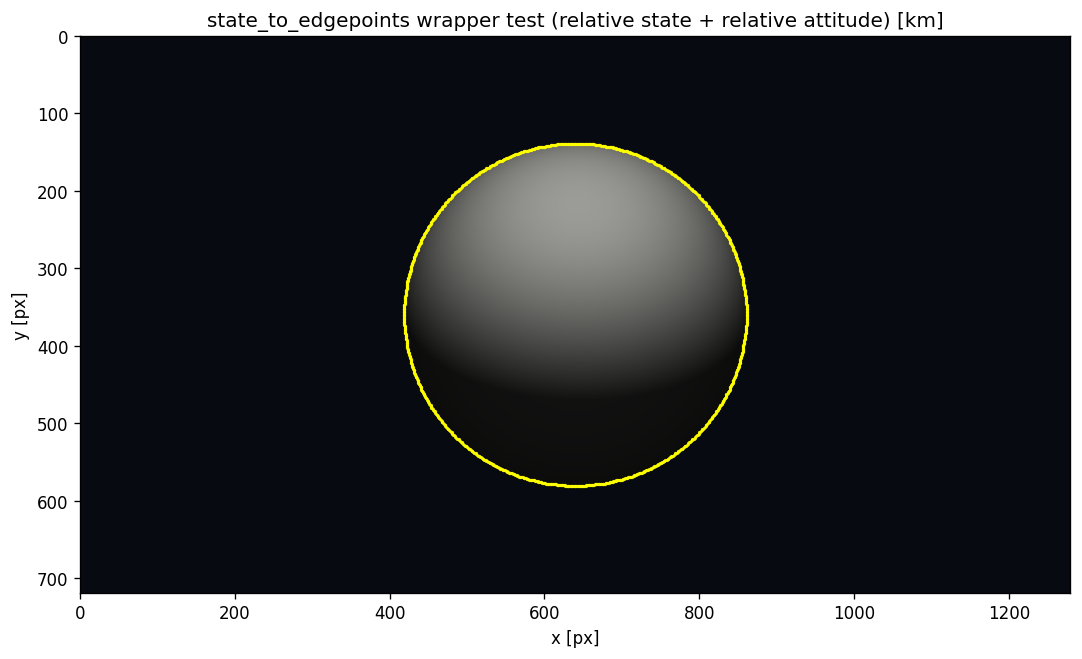

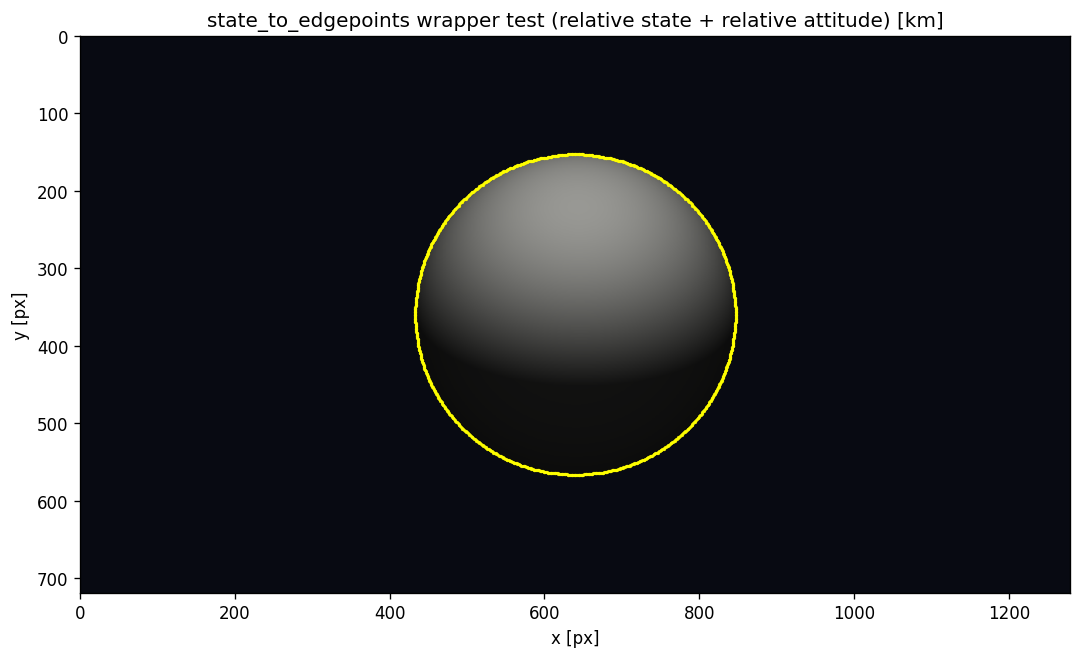

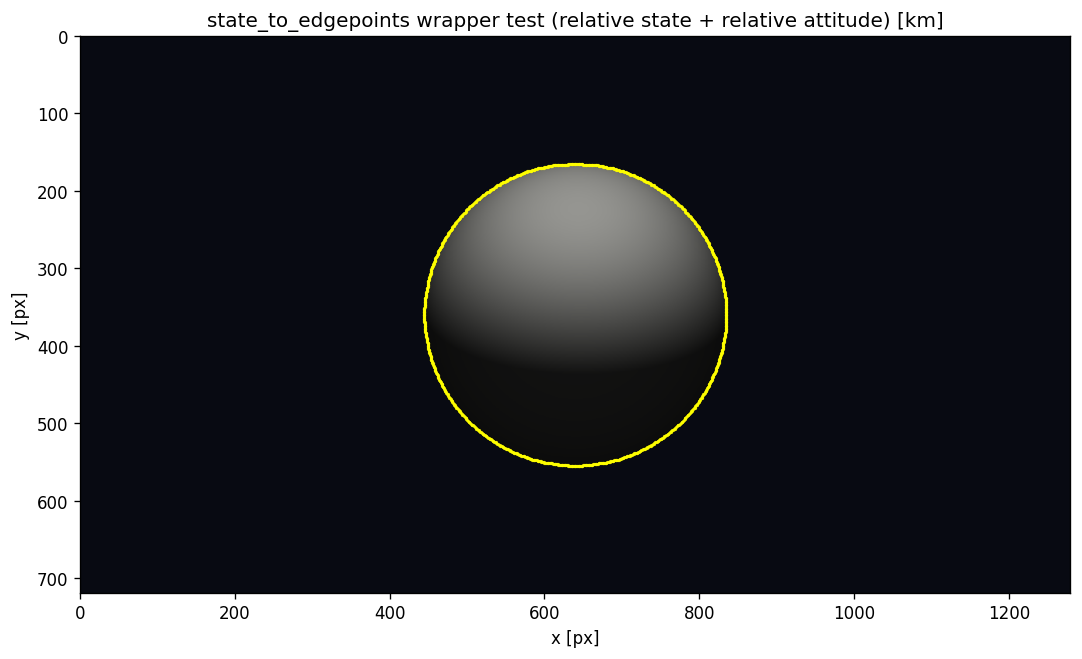

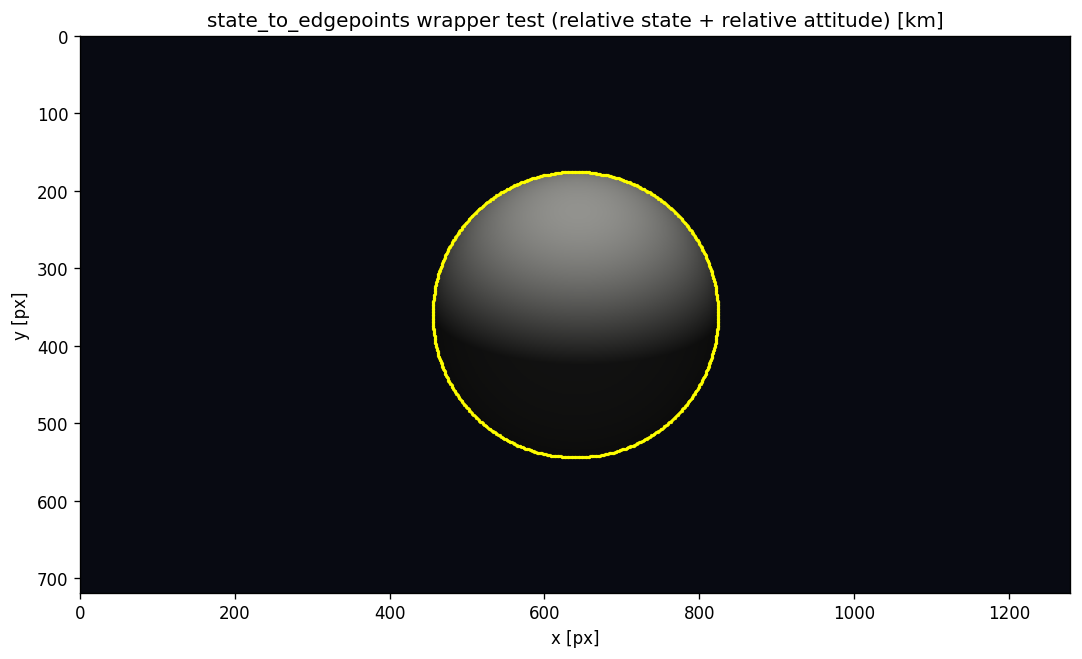

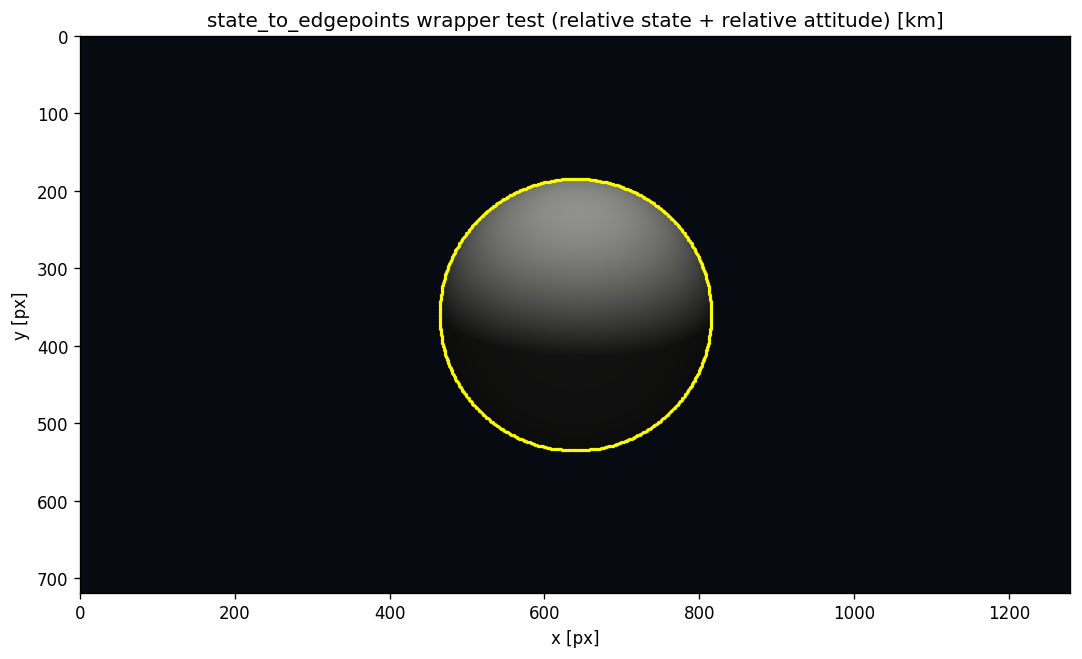

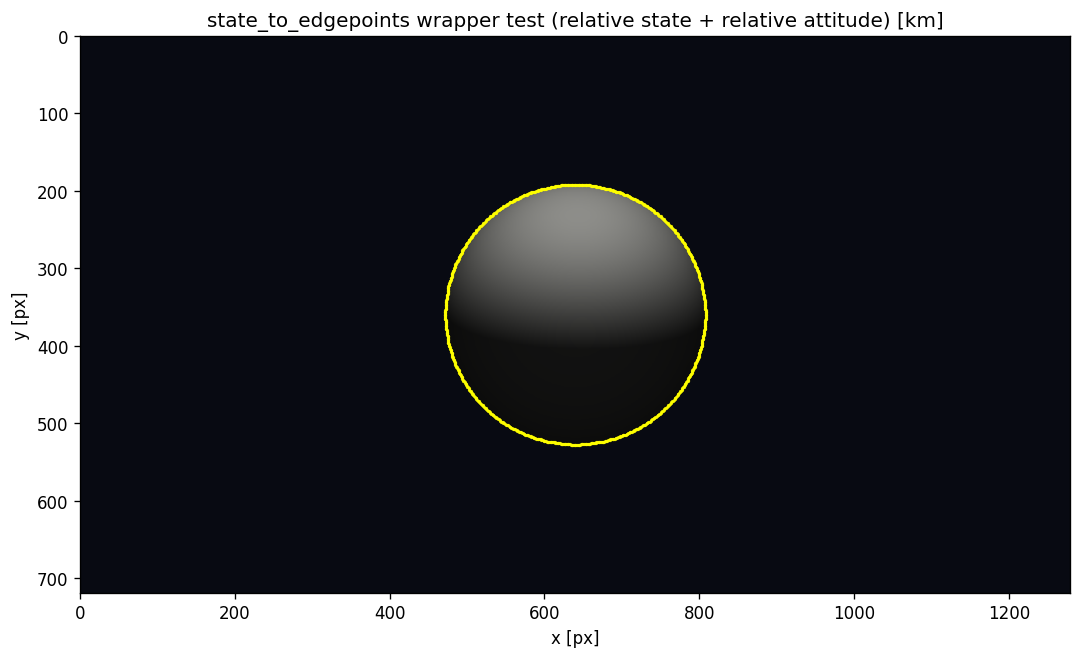

In [49]:

i = 0
for out in outs:
    i += 1
    if i % 1 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=None,
            y_limits=None,
        )

In [50]:

# Test CR Algorithm on Reference Trajectory
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing
rho_p_est = []  # Will store satellite position vector (planet frame)
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)  # T_c_p: camera to planet frame rotation
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    # Negate rp_est to get satellite position in planet frame (consistent with orientation of truth positions)
    rho_p_est.append(-rp_est)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [  -0.     -0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [-0.   -0.    9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [   0.      0.   7081.89] (7081.89 km)
 - (C->P in planet frame): [ 4966.66 -5047.35   -99.33] (7081.89 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   7069.25] (7069.25 km)
 - (C->P in planet frame): [ 4957.79 -5038.34   -99.16] (7069.25 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   12.64] (12.64 km)
 - (Planet frame): [ 8.87 -9.01 -0.18] (12.64 km)
Distance error: 12.64 km (0.178826%)
Ang

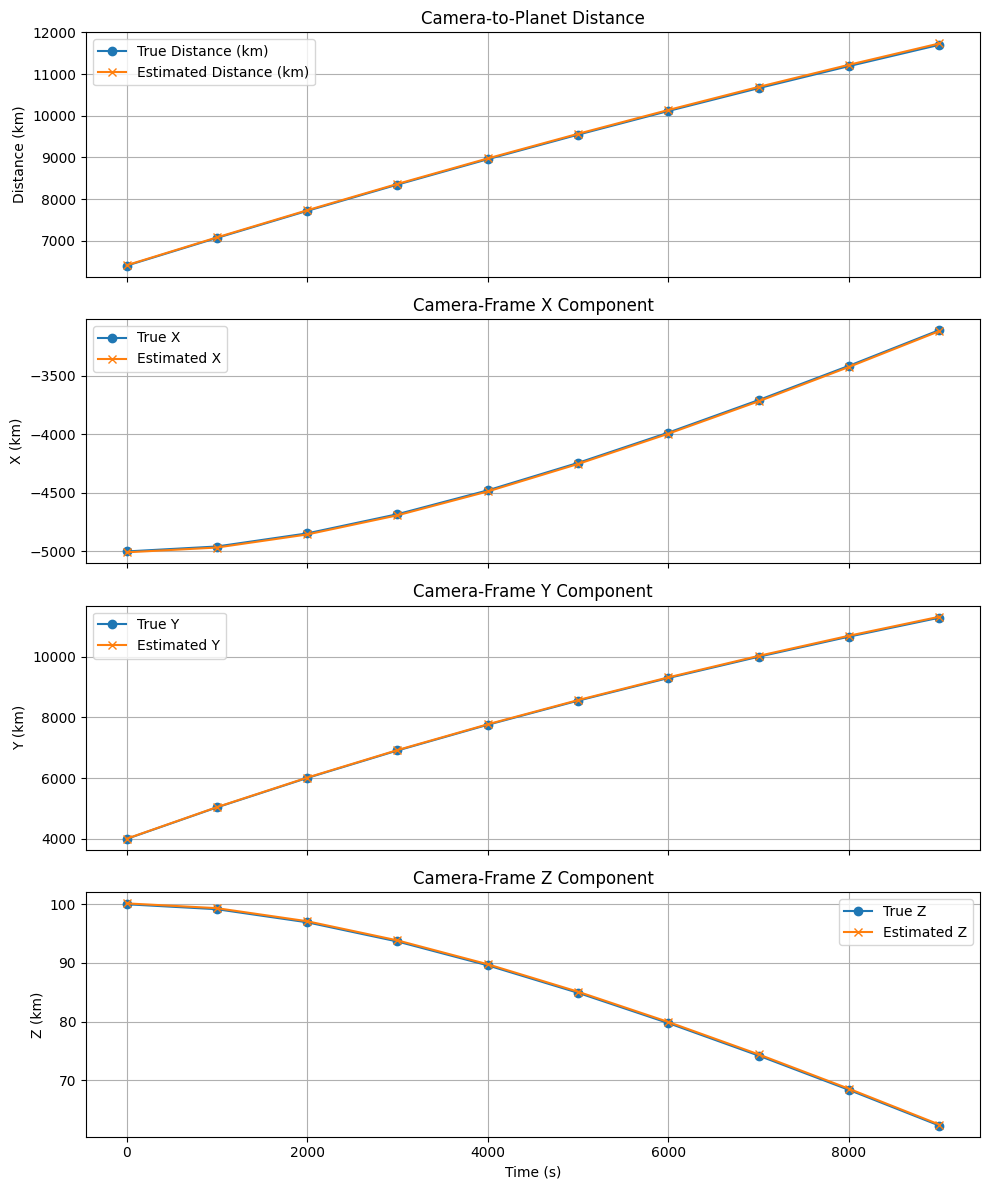

In [51]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
rho_p_est = np.array(rho_p_est)
times = np.array(times)

#print(np.shape(pos))
#print(estimates[:, 1])
#print("times:", times)

# plt.plot()


plot_est_dist_xyz(
    times,
    pos,
    rho_p_est,
    
)

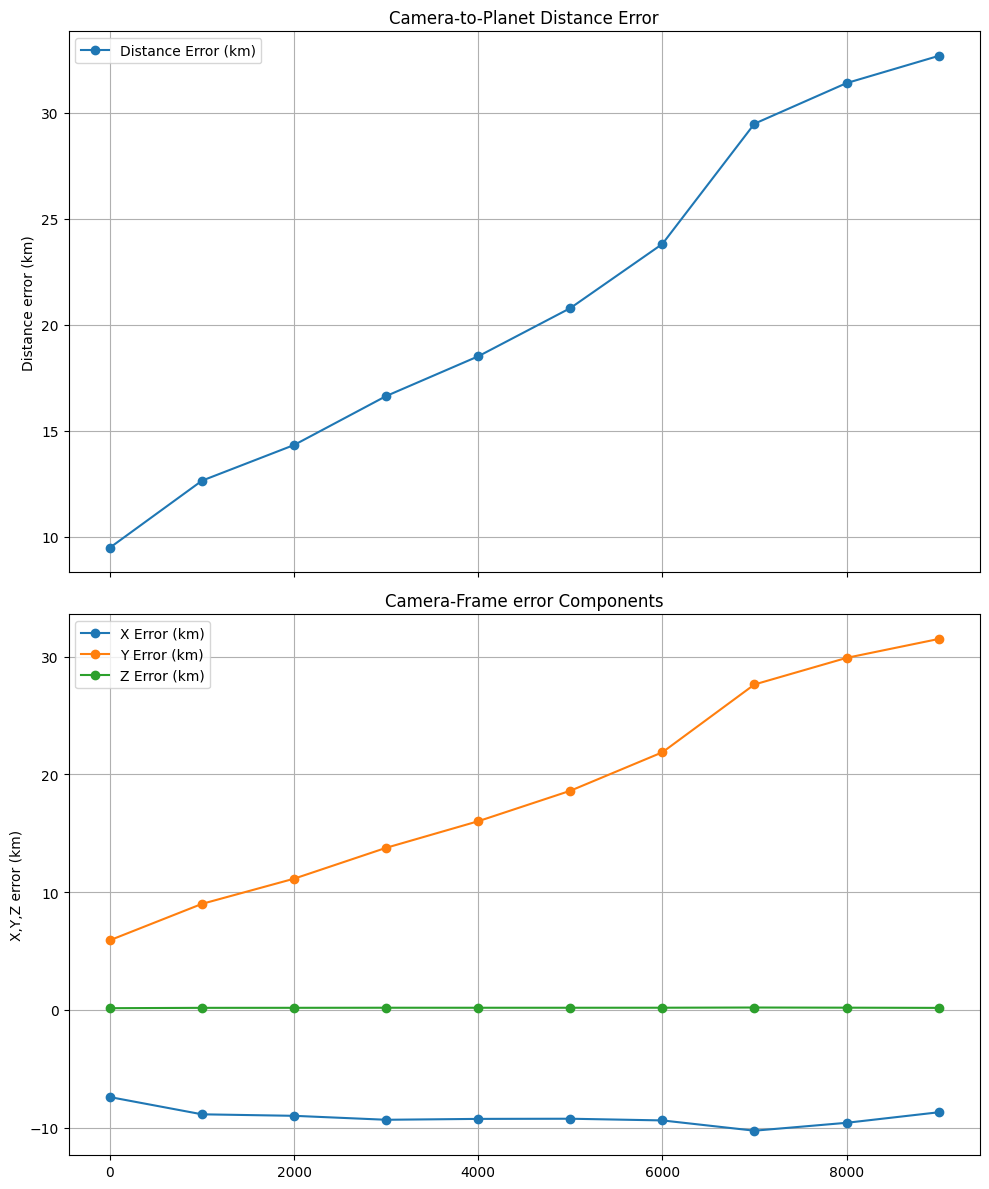

In [52]:
plot_est_dist_xyz_errors(
    times,
    pos,
    rho_p_est,
)

In [53]:
# EKF Configuration
Q = np.diag([Q_POS_VARIANCE, Q_POS_VARIANCE, Q_POS_VARIANCE, 
             Q_VEL_VARIANCE, Q_VEL_VARIANCE, Q_VEL_VARIANCE])  # Process noise covariance

Q_perfect = np.zeros((6, 6))  # Perfect process model (no noise)

R = np.diag([R_MEAS_VARIANCE, R_MEAS_VARIANCE, R_MEAS_VARIANCE])  # Measurement noise covariance

dt = TRAJECTORY_DT  # Time step in seconds
N = N_STEPS

state_0 = np.array(State0)
mu0 = state_0
sigma0 = np.diag([1.0, 1.0, 1.0, 0.0001, 0.0001, 0.0001])  # Initial state covariance

central_body_mass = MOON_MU / G  # kg, derived from MOON_MU / G

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)

state_0=array([-5.000e+03,  4.000e+03,  1.000e+02,  0.000e+00,  1.075e+00,
        0.000e+00])


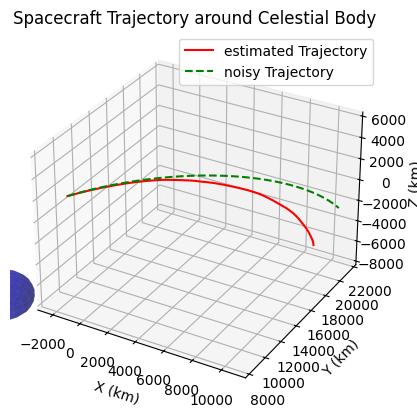

In [ ]:
print(f"{state_0=}")
states_perfect = []
states_noisy = []

state_clean = state
state_noisy = state + noise(Q)

t = 0

# get noisy trajectory for EKF testing
for i in range(N):
    states_perfect.append(state_clean)
    states_noisy.append(state_noisy)
    
    # Perfect trajectory (for comparison)
    state_next_clean = ekf.f_func(state_clean) 

    # Noisy/realistic trajectory
    process_noise = noise(Q)
    state_next_noisy = ekf.f_func(state_noisy) + process_noise

    t += dt
    states_perfect.append(state_next_clean)
    states_noisy.append(state_next_noisy)

    state_noisy = state_next_noisy
    state_clean = state_next_clean 

states_noisy = np.array(states_noisy)
states_perfect = np.array(states_perfect)

ts = np.arange(0, N) * dt # Stops *just* before N*dt though so maybe we do N+1?

plot_trajs(states_noisy, states_perfect, body_struct)

In [64]:
# get CR estimates for EKF measurement updates
print(ts[i])
print(states_noisy[i])
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)


49000
[ 1.146e+04  1.630e+04 -2.005e+03  1.718e-01 -2.622e-01 -3.877e-02]
State at t=0.0s: [-3.112e+03  1.128e+04  6.190e+01  3.163e-01  5.882e-01 -1.035e-02]
State at t=1000.0s: [-2.791e+03  1.185e+04  5.170e+01  3.358e-01  5.524e-01  4.012e-03]
State at t=2000.0s: [-2.451e+03  1.239e+04  5.553e+01  3.517e-01  5.312e-01  7.103e-04]
State at t=3000.0s: [-2.094e+03  1.291e+04  5.453e+01  3.513e-01  4.973e-01  1.764e-03]
State at t=4000.0s: [-1.740e+03  1.339e+04  5.796e+01  3.490e-01  4.639e-01 -1.190e-02]
State at t=5000.0s: [-1.389e+03  1.384e+04  4.544e+01  3.708e-01  4.458e-01  2.084e-03]
State at t=6000.0s: [-1.017e+03  1.427e+04  4.851e+01  3.683e-01  4.320e-01 -1.183e-02]
State at t=7000.0s: [-6.490e+02  1.469e+04  3.833e+01  3.840e-01  3.948e-01 -1.582e-03]
State at t=8000.0s: [-2.642e+02  1.508e+04  3.716e+01  3.830e-01  3.586e-01 -3.690e-03]
State at t=9000.0s: [ 1.183e+02  1.542e+04  3.439e+01  3.864e-01  3.378e-01 -7.888e-03]
State at t=10000.0s: [ 5.043e+02  1.575e+04  2.66

In [65]:
# Generate Measurements from Noisy Trajectory
rp_est_CR = []  # CR estimates in planet frame
rc_est_CR = []  # CR measurements in camera frame
planet_to_camera_rotations = []  # T_c_p matrices for each timestep
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)
    planet_to_camera_rotations.append(T_c_p)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet location in planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    rp_est_CR.append(rp_est)
    rc_est_CR.append(rc_est)

Running CR alg on image 1/50
Calc Position:
 - (C->P in camera frame): [   -0.      -0.   11735.56] (11735.56 km)
 - (C->P in planet frame): [  3120.91 -11312.8     -62.07] (11735.56 km)
Actual position:
 - (C->P in camera frame): [   -0.      -0.   11702.32] (11702.32 km)
 - (C->P in planet frame): [  3112.07 -11280.76    -61.9 ] (11702.32 km)
Est Error - Actual:
 - (Camera frame): [-0.   -0.   33.24] (33.24 km)
 - (Planet frame): [  8.84 -32.04  -0.18] (33.24 km)
Distance error: 33.24 km (0.284053%)
Angular error: 0.0000 degrees
Running CR alg on image 2/50
Calc Position:
 - (C->P in camera frame): [   -0.       0.   12211.68] (12211.68 km)
 - (C->P in planet frame): [  2798.85 -11886.5     -51.85] (12211.68 km)
Actual position:
 - (C->P in camera frame): [   -0.      -0.   12176.86] (12176.86 km)
 - (C->P in planet frame): [  2790.87 -11852.61    -51.7 ] (12176.86 km)
Est Error - Actual:
 - (Camera frame): [-0.    0.   34.82] (34.82 km)
 - (Planet frame): [  7.98 -33.89  -0.15] (34.

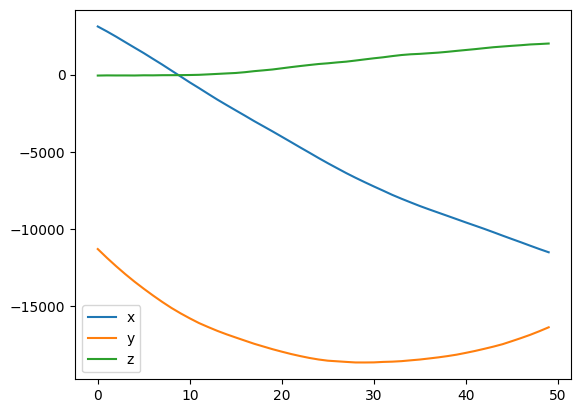

In [66]:
# Plot CR estimates in planet frame
plt.plot(rp_est_CR)
plt.legend(["x", "y", "z"])

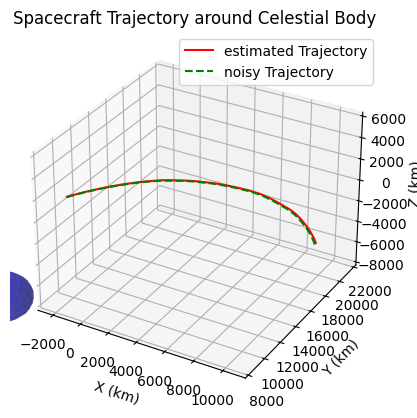

In [67]:
rp_est_CR = np.array(rp_est_CR)

plot_trajs(-rp_est_CR, states_noisy, body_struct)

In [68]:
# EKF Estimation Loop
mus = []  # EKF state estimates over time
sigmas = []  # EKF covariances over time
for i in range(N):
    print(f"EKF step {i+1}/{N}")
    ekf.predict()
    measurement = -rc_est_CR[i]  # Negate for measurement model
    print("Measurement:", measurement)
    print("Predicted state:", ekf.mu)
    ekf.update(measurement, planet_to_camera_rotations[i])
    mus.append(ekf.mu)
    sigmas.append(ekf.sigma)

print("Final EKF state estimate:", ekf.mu)

EKF step 1/50
Measurement: [ 9.166e-13  2.104e-11 -1.174e+04]
Predicted state: [ 1.171e+04  1.615e+04 -2.057e+03  1.953e-01 -2.537e-01 -3.416e-02]
Measurement function output: [  1823.679 -15625.223 -12446.958]
EKF step 2/50
Measurement: [ 1.229e-12 -7.330e-12 -1.221e+04]
Predicted state: [ 5.590e+02  1.218e+04 -4.692e+02 -2.948e+00 -1.307e+00  4.157e-01]
Measurement function output: [   458.781  -3343.387 -11720.707]
EKF step 3/50
Measurement: [ 2.629e-13 -1.874e-12 -1.267e+04]
Predicted state: [-4.952e+03  1.063e+04  3.449e+02 -3.652e+00 -1.403e+00  5.261e-01]
Measurement function output: [  -232.631   2802.168 -11387.651]
EKF step 4/50
Measurement: [-4.832e-13  1.417e-11 -1.311e+04]
Predicted state: [-6.697e+03  1.059e+04  6.498e+02 -3.118e+00 -1.051e+00  4.647e-01]
Measurement function output: [  -475.308   4927.627 -11530.585]
EKF step 5/50
Measurement: [ 9.237e-13 -9.509e-12 -1.355e+04]
Predicted state: [-6.306e+03  1.133e+04  6.603e+02 -2.143e+00 -5.822e-01  3.388e-01]
Measureme

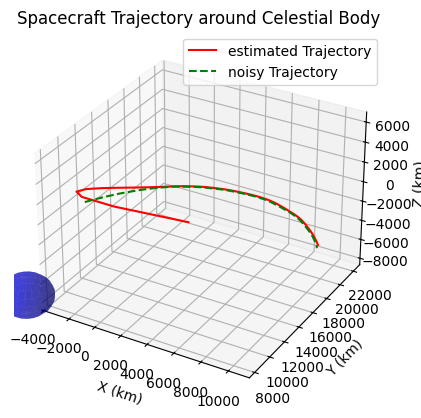

In [69]:
mus = np.array(mus)
sigmas = np.array(sigmas)
plot_trajs(mus, states_noisy, body_struct)


Final EKF state estimate: [ 1.151e+04  1.640e+04 -2.022e+03  2.022e-01 -2.439e-01 -3.538e-02]


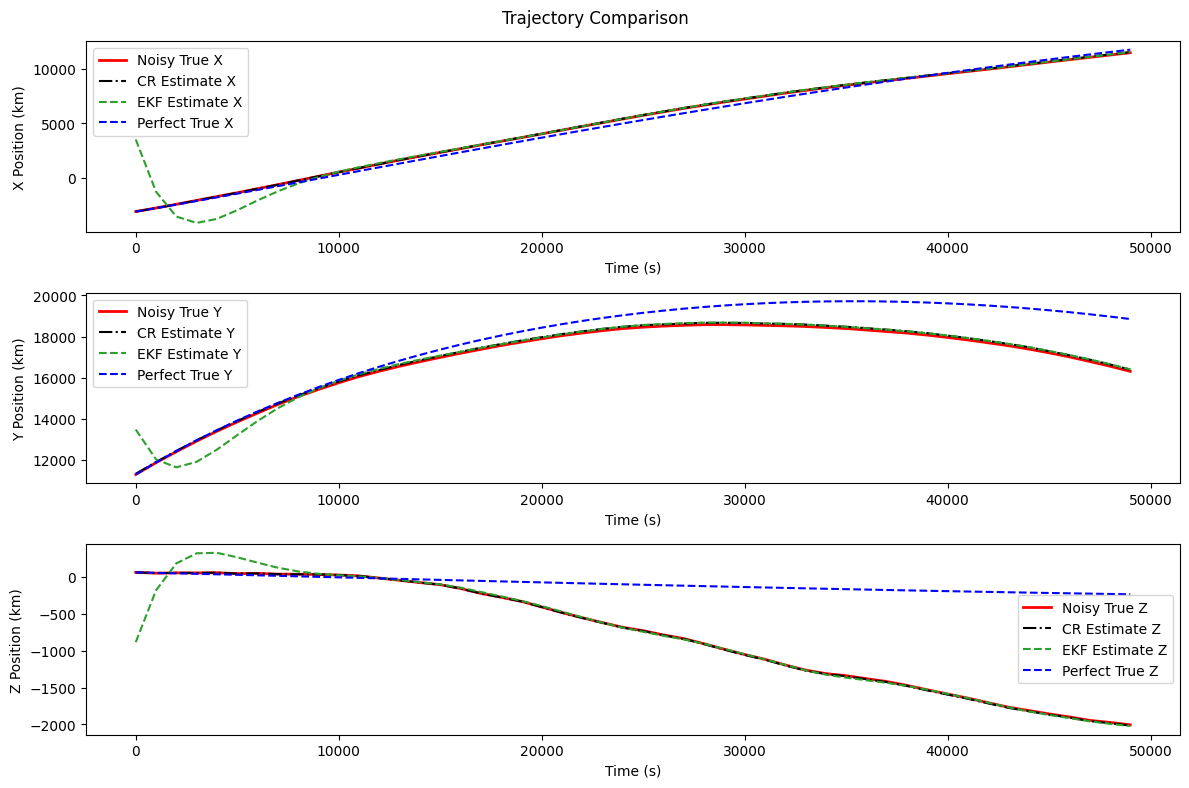

In [162]:
# plot EKF estimates vs true trajectory and CR estimates vs time
mus = np.array(mus)
states_noisy = np.array(states_noisy)
    

plt.figure(figsize=(12, 8))
plt.suptitle("Trajectory Comparison")
plt.subplot(3, 1, 1)
print("Final EKF state estimate:", ekf.mu)
# Align array lengths with ts (mus and states_noisy are length 51, ts is 50)
mus = mus[:len(ts)]
states_noisy = states_noisy[:len(ts)]
plt.plot(ts, states_noisy[:, 0], label='Noisy True X', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 0], label='CR Estimate X', color='k', linestyle='-.')
plt.plot(ts, mus[:, 0], label='EKF Estimate X', color='tab:green', linestyle='--')
plt.plot(ts, states_perfect[:, 0], label='Perfect True X', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('X Position (km)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(ts, states_noisy[:, 1], label='Noisy True Y', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 1], label='CR Estimate Y', color='k', linestyle='-.')
plt.plot(ts, mus[:, 1], label='EKF Estimate Y', color='tab:green', linestyle='--')
plt.plot(ts, states_perfect[:, 1], label='Perfect True Y', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (km)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(ts, states_noisy[:, 2], label='Noisy True Z', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 2], label='CR Estimate Z', color='k', linestyle='-.')
plt.plot(ts, mus[:, 2], label='EKF Estimate Z', color='tab:green', linestyle='--')
plt.plot(ts, states_perfect[:, 2], label='Perfect True Z', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (km)')
plt.legend()
plt.tight_layout()
plt.show()

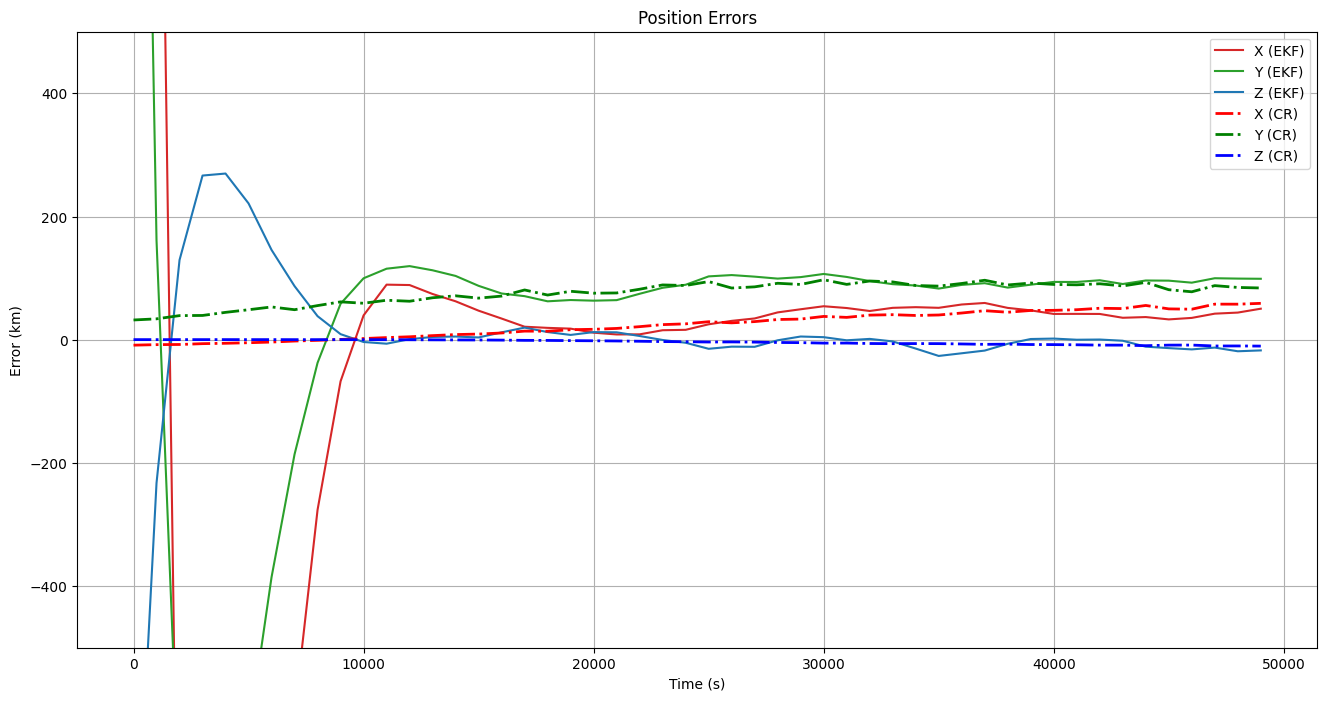

In [ ]:
EKF_err = mus - states_noisy
CR_err = (-rp_est_CR) - states_noisy[:,:3]



plt.figure(figsize=(16, 8))


# plt.subplot(2, 1, 1)
plt.title("Position Errors")
plt.plot(ts, EKF_err[:,0], label='X (EKF)', color="tab:red")
plt.plot(ts, EKF_err[:,1], label='Y (EKF)', color="tab:green")
plt.plot(ts, EKF_err[:,2], label='Z (EKF)', color="tab:blue")
plt.plot(ts, CR_err[:,0], "-.", label='X (CR)', color="red", linewidth=2)
plt.plot(ts, CR_err[:,1], "-.", label='Y (CR)', color="green", linewidth=2)
plt.plot(ts, CR_err[:,2], "-.", label='Z (CR)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Error (km)')
plt.ylim(-500, 500)
plt.grid(True)
plt.legend()
plt.show()


# # plt.subplot(2, 1, 2)
# plt.title("Velocity Errors")
# plt.plot(ts, EKF_err[:,3], label='X (EKF)')
# plt.plot(ts, EKF_err[:,4], label='Y (EKF)')
# plt.plot(ts, EKF_err[:,5], label='Z (EKF)')
# plt.plot(ts, CR_err[:,0], "-.", label='X (CR)')
# plt.plot(ts, CR_err[:,1], "-.", label='Y (CR)')
# plt.plot(ts, CR_err[:,2], "-.", label='Z (CR)')
# plt.xlabel('Time (s)')
# plt.ylabel('Error (km/s)')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
plt.show()



In [141]:
rp_est_CR_norm = np.apply_along_axis(np.linalg.norm, 1, rp_est_CR[:,:3])
rp_est_EKF_norm = np.apply_along_axis(np.linalg.norm, 1, mus[:,:3])

state_norm_perfect = np.apply_along_axis(np.linalg.norm, 1, states_perfect[:,:3])
state_norm_noisy = np.apply_along_axis(np.linalg.norm, 1, states_noisy[:,:3])

EKF State 0 Error: [56.53 18.71 -8.08 -0.03 -0.02  0.  ]


<Figure size 1000x600 with 0 Axes>

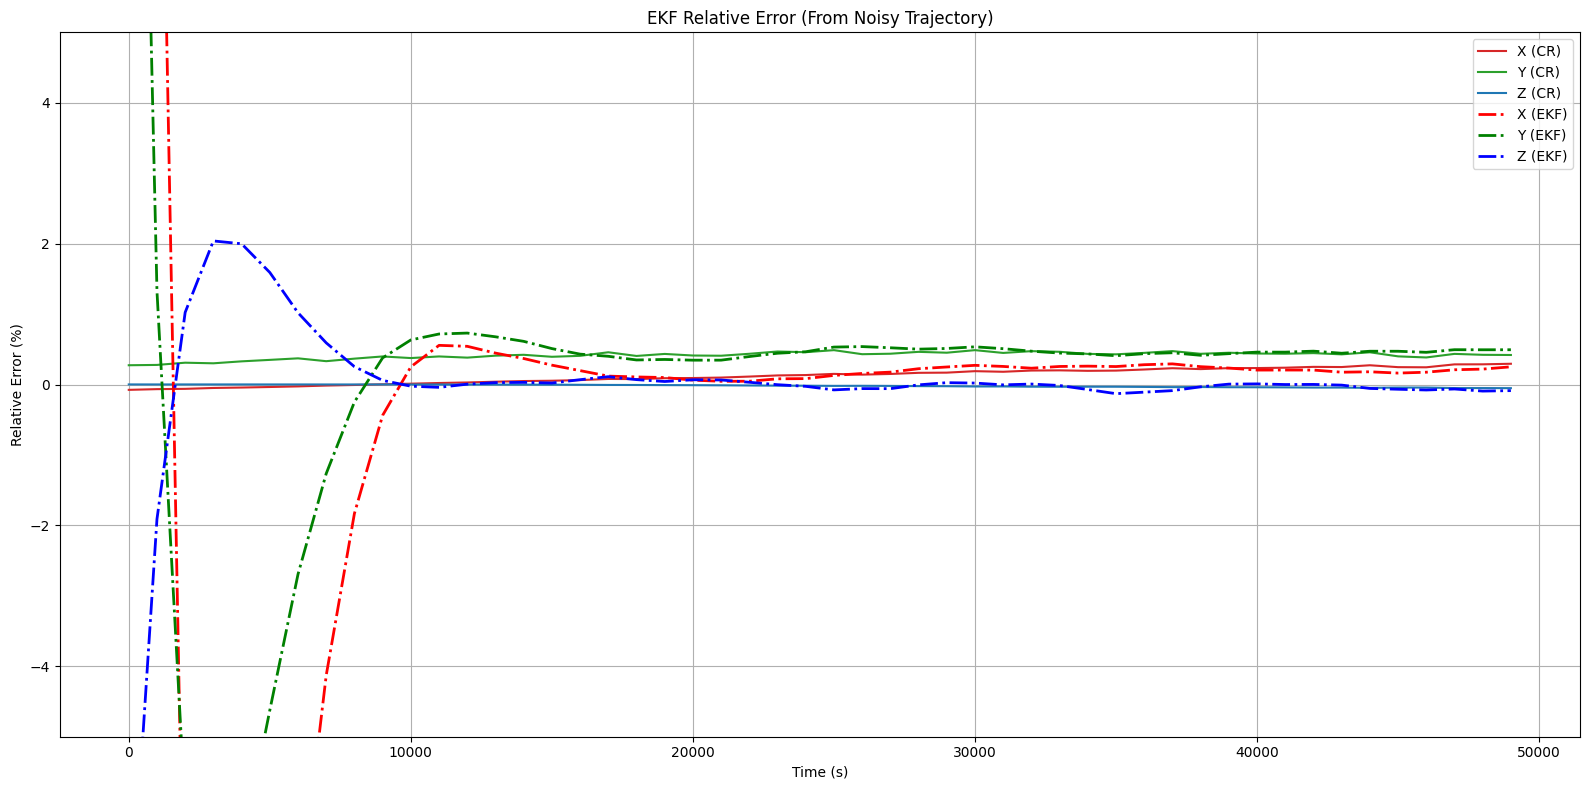

CR State 0 Error: [-0.076  0.274  0.002]
CR State 0 Error: 0.28405334612176947
EKF State 0 Error: [56.531 18.707 -8.084]
EKF State 0 Error: 60.09197261989491
CR State -1 Error: [ 0.295  0.419 -0.052]
CR State -1 Error: 0.5151860660625248
EKF State -1 Error: [ 0.251  0.494 -0.087]
EKF State -1 Error: 0.560948997365411


In [171]:
CR_err_rel = 100*CR_err / state_norm_noisy[:,None]
EKF_err_rel = 100*EKF_err / state_norm_noisy[:,None]

np.set_printoptions(precision=3, suppress=True)



print(f"EKF State 0 Error: {np.round(EKF_err_rel[0], 2)}")

plt.figure(figsize=(10, 6))

plt.figure(figsize=(16, 8))
plt.title("EKF Relative Error (From Noisy Trajectory)")
plt.plot(ts, CR_err_rel[:,0], label='X (CR)', color="tab:red")
plt.plot(ts, CR_err_rel[:,1], label='Y (CR)', color="tab:green")
plt.plot(ts, CR_err_rel[:,2], label='Z (CR)', color="tab:blue")
plt.plot(ts, EKF_err_rel[:,0], "-.", label='X (EKF)', color="red", linewidth=2)
plt.plot(ts, EKF_err_rel[:,1], "-.", label='Y (EKF)', color="green", linewidth=2)
plt.plot(ts, EKF_err_rel[:,2], "-.", label='Z (EKF)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Relative Error (%)')
plt.legend()
plt.ylim(-5, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

CR_0 = CR_err_rel[0]
EKF_0 = EKF_err_rel[0, :3]

print(f"CR State 0 Error: {CR_0}")
print(f"CR State 0 Error: {norm(CR_0)}")
print(f"EKF State 0 Error: {EKF_0}")
print(f"EKF State 0 Error: {norm(EKF_0)}")

CR_0 = CR_err_rel[-1]
EKF_0 = EKF_err_rel[-1, :3]

print(f"CR State -1 Error: {CR_0}")
print(f"CR State -1 Error: {norm(CR_0)}")
print(f"EKF State -1 Error: {EKF_0}")
print(f"EKF State -1 Error: {norm(EKF_0)}")